In [4]:
from google.colab import files
uploaded = files.upload()    # This opens a file picker
# After upload, read it:
import pandas as pd
df = pd.read_excel(next(iter(uploaded)))
df.head()


Saving 1730285881-Airbnb_Open_Data.xlsx to 1730285881-Airbnb_Open_Data.xlsx


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [5]:
import pandas as pd
df = pd.read_excel("1730285881-Airbnb_Open_Data.xlsx")
df.head()


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


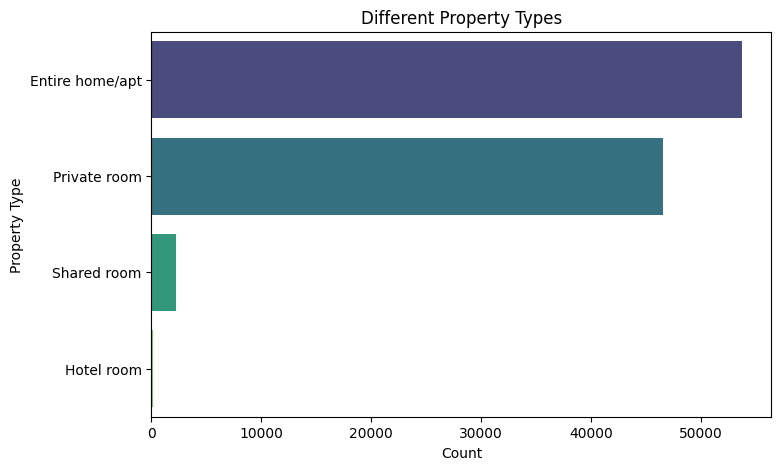

In [9]:
# Count of property types
property_counts = df['room type'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=property_counts.values, y=property_counts.index, palette="viridis", hue=property_counts.index, legend=False)
plt.title("Different Property Types")
plt.xlabel("Count")
plt.ylabel("Property Type")
plt.show()

In [7]:
print(df.columns)

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')


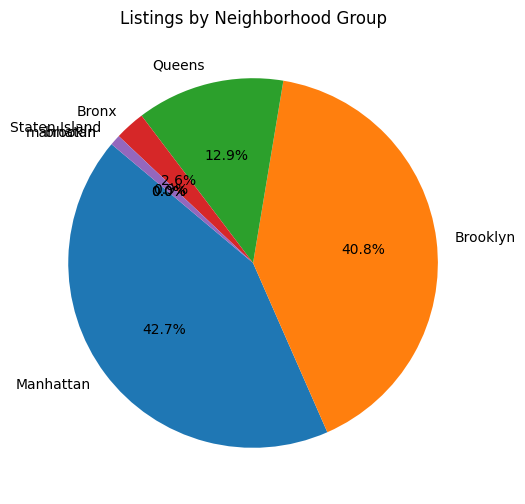

In [11]:
ng_counts = df['neighbourhood group'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(ng_counts, labels=ng_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Listings by Neighborhood Group")
plt.show()

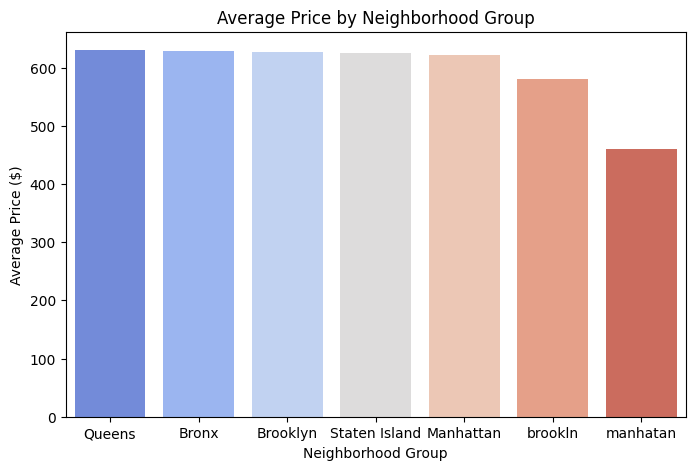

In [13]:
avg_price = df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_price.index, y=avg_price.values, palette="coolwarm", hue=avg_price.index, legend=False)
plt.title("Average Price by Neighborhood Group")
plt.xlabel("Neighborhood Group")
plt.ylabel("Average Price ($)")
plt.show()

In [14]:
if 'year_built' in df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='year_built', y='price', data=df, alpha=0.4)
    plt.title("Price vs Construction Year")
    plt.xlabel("Construction Year")
    plt.ylabel("Price ($)")
    plt.show()
else:
    print("No 'year_built' column found.")


No 'year_built' column found.


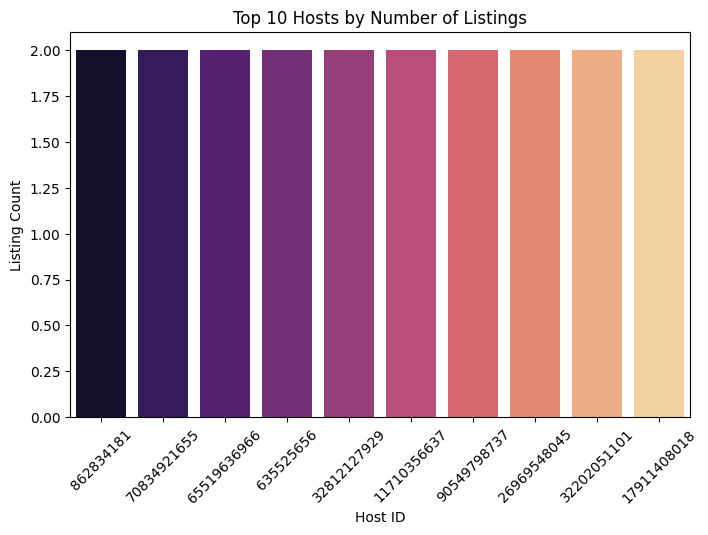

In [17]:
top_hosts = df['host id'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_hosts.index.astype(str), y=top_hosts.values, palette="magma", hue=top_hosts.index.astype(str), legend=False)
plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Host ID")
plt.ylabel("Listing Count")
plt.xticks(rotation=45)
plt.show()

In [18]:
if {'host_identity_verified','review_scores_rating'}.issubset(df.columns):
    sns.boxplot(x='host_identity_verified', y='review_scores_rating',
                data=df, palette="Set2")
    plt.title("Review Scores by Host Verification Status")
    plt.xlabel("Host Verified")
    plt.ylabel("Review Score")
    plt.show()
else:
    print("Required columns not found.")


Required columns not found.


In [19]:
if {'price','service_fee'}.issubset(df.columns):
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='service_fee', y='price', data=df, alpha=0.4)
    plt.title("Price vs Service Fee")
    plt.xlabel("Service Fee ($)")
    plt.ylabel("Price ($)")
    plt.show()

    corr = df['price'].corr(df['service_fee'])
    print("Correlation coefficient:", round(corr, 3))
else:
    print("No 'service_fee' column found.")


No 'service_fee' column found.
